In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

# Data and analysis libraries
import polars as pl                         # Fast dataframes for financial data
import numpy as np                          # Numerical computing library
from datetime import datetime, timedelta    # Date and time operations
import random


# Machine learning libraries  
import torch                                # PyTorch framework
import torch.nn as nn                       # Neural network modules
import torch.optim as optim                 # Optimization algorithms
import research                             # Model building and training utilities


# Visualization and 
import altair as alt                        # Interactive visualization library

# data sources
import binance                              # Binance market data utilities

In [2]:
research.set_seed(42)

In [3]:
pl.Config.set_tbl_width_chars(200)
pl.Config.set_fmt_str_lengths(100)
pl.Config.set_tbl_cols(-1)  # Show all columns

polars.config.Config

In [4]:
# Trading pair symbol
sym = 'BTCUSDT'
# time horizon of time series (time interval)
time_interval = '1h'
# Max number of auto-regressive lags
max_lags = 4
# Forecast horizon in steps 
forecast_horizon = 1
# Sharpe annualized rate (so it's independent of time frequency)
annualized_rate = research.sharpe_annualization_factor(time_interval, 365, 24)

In [5]:
import binance
print(binance.__file__)
print([x for x in dir(binance) if "download" in x.lower()])

c:\Users\micha\Documents\Code\school\cpp\classes\spring-2026\mat_4860\quant_trading_strategy\ML-Systematic-Trading-Engine\binance.py
['download_and_unzip', 'download_date_range', 'download_ohlc_timeseries', 'download_timeseries', 'download_trades']


In [6]:
# Download Data
start_date = datetime(2024, 10, 29, 0, 0)
end_date = datetime(2025, 10, 9, 0, 0)
binance.download_date_range(sym, start_date, end_date)

In [7]:
ts = research.load_ohlc_timeseries_range(sym, time_interval, start_date, end_date)
ts

Loading BTCUSDT: 100%|██████████| 346/346 [01:12<00:00,  4.78day/s]


datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2024-10-29 00:00:00,69939.9,69998.4,69733.0,69939.5
2024-10-29 01:00:00,69939.5,70399.4,69810.8,70287.0
2024-10-29 02:00:00,70286.9,71607.0,70198.1,71173.9
2024-10-29 03:00:00,71173.8,71409.0,70870.2,70927.5
2024-10-29 04:00:00,70927.4,71123.4,70906.1,71062.6
…,…,…,…,…
2025-10-09 19:00:00,120600.0,121060.1,120600.0,120897.6
2025-10-09 20:00:00,120897.6,121147.2,120787.9,121045.4
2025-10-09 21:00:00,121045.3,121457.2,120998.3,121407.8


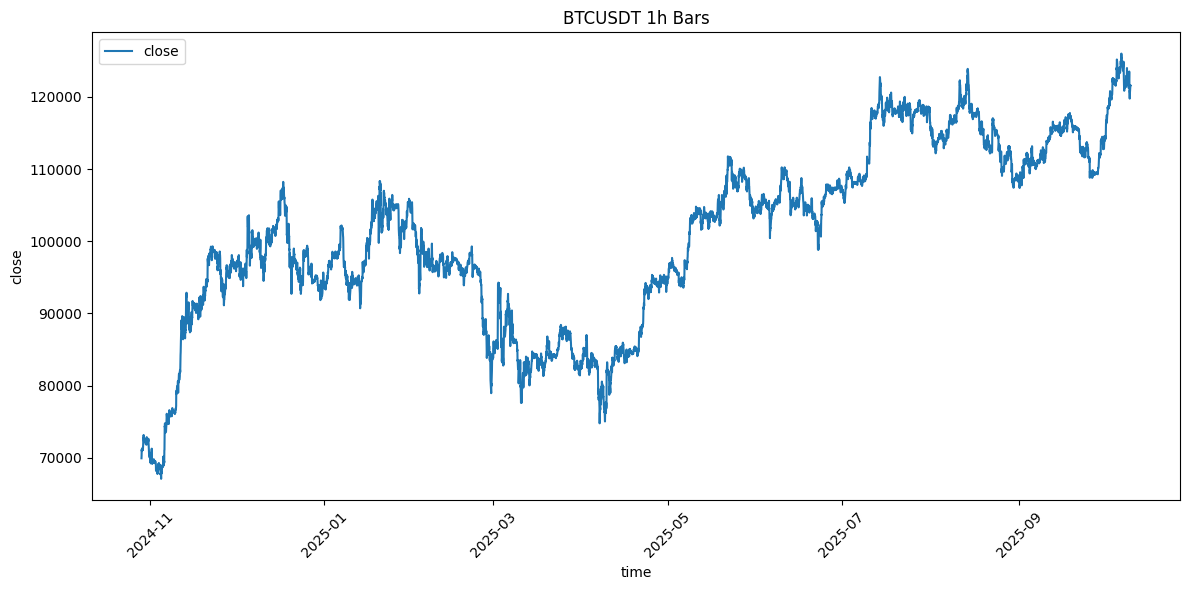

In [8]:
research.plot_static_timeseries(ts, sym, 'close', time_interval)

In [9]:
alt.data_transformers.enable("vegafusion")
research.plot_dyn_timeseries(ts, sym, 'close', time_interval)

alt.Chart(...)

### Feature Engineering

In [10]:
price_time_series = pl.DataFrame({'price':[100.0,120.0,100.0]})
research.plot_column(price_time_series, 'price')

alt.Chart(...)

In [11]:
price_time_series.with_columns(
    pl.col('price').diff().alias('delta'),
    ((pl.col('price')-pl.col('price').shift())/pl.col('price').shift()).alias('return'),
    (pl.col('price')/pl.col('price').shift()).log().alias('log_return'),
)

price,delta,return,log_return
f64,f64,f64,f64
100.0,null,null,null
120.0,20.0,0.2,0.182322
100.0,-20.0,-0.166667,-0.182322


### Create target and lagged features

In [12]:
ts = ts.with_columns((pl.col('close')/pl.col('close').shift(forecast_horizon)).log().alias('close_log_return'))
ts

datetime,open,high,low,close,close_log_return
datetime[μs],f64,f64,f64,f64,f64
2024-10-29 00:00:00,69939.9,69998.4,69733.0,69939.5,null
2024-10-29 01:00:00,69939.5,70399.4,69810.8,70287.0,0.004956
2024-10-29 02:00:00,70286.9,71607.0,70198.1,71173.9,0.012539
2024-10-29 03:00:00,71173.8,71409.0,70870.2,70927.5,-0.003468
2024-10-29 04:00:00,70927.4,71123.4,70906.1,71062.6,0.001903
…,…,…,…,…,…
2025-10-09 19:00:00,120600.0,121060.1,120600.0,120897.6,0.002465
2025-10-09 20:00:00,120897.6,121147.2,120787.9,121045.4,0.001222
2025-10-09 21:00:00,121045.3,121457.2,120998.3,121407.8,0.002989


In [13]:
target = 'close_log_return'
lr = pl.col(target)
ts = ts.with_columns(
    lr.shift(forecast_horizon * 1).alias(f'{target}_lag_1'),
    lr.shift(forecast_horizon * 2).alias(f'{target}_lag_2'),
    lr.shift(forecast_horizon * 3).alias(f'{target}_lag_3'),
    lr.shift(forecast_horizon * 4).alias(f'{target}_lag_4'),
)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2024-10-29 00:00:00,69939.9,69998.4,69733.0,69939.5,null,null,null,null,null
2024-10-29 01:00:00,69939.5,70399.4,69810.8,70287.0,0.004956,null,null,null,null
2024-10-29 02:00:00,70286.9,71607.0,70198.1,71173.9,0.012539,0.004956,null,null,null
2024-10-29 03:00:00,71173.8,71409.0,70870.2,70927.5,-0.003468,0.012539,0.004956,null,null
2024-10-29 04:00:00,70927.4,71123.4,70906.1,71062.6,0.001903,-0.003468,0.012539,0.004956,null
…,…,…,…,…,…,…,…,…,…
2025-10-09 19:00:00,120600.0,121060.1,120600.0,120897.6,0.002465,-0.002613,0.009669,-0.011023,-0.001285
2025-10-09 20:00:00,120897.6,121147.2,120787.9,121045.4,0.001222,0.002465,-0.002613,0.009669,-0.011023
2025-10-09 21:00:00,121045.3,121457.2,120998.3,121407.8,0.002989,0.001222,0.002465,-0.002613,0.009669


In [14]:
ts = research.add_lags(ts, target, max_lags, forecast_horizon)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2024-10-29 00:00:00,69939.9,69998.4,69733.0,69939.5,null,null,null,null,null
2024-10-29 01:00:00,69939.5,70399.4,69810.8,70287.0,0.004956,null,null,null,null
2024-10-29 02:00:00,70286.9,71607.0,70198.1,71173.9,0.012539,0.004956,null,null,null
2024-10-29 03:00:00,71173.8,71409.0,70870.2,70927.5,-0.003468,0.012539,0.004956,null,null
2024-10-29 04:00:00,70927.4,71123.4,70906.1,71062.6,0.001903,-0.003468,0.012539,0.004956,null
…,…,…,…,…,…,…,…,…,…
2025-10-09 19:00:00,120600.0,121060.1,120600.0,120897.6,0.002465,-0.002613,0.009669,-0.011023,-0.001285
2025-10-09 20:00:00,120897.6,121147.2,120787.9,121045.4,0.001222,0.002465,-0.002613,0.009669,-0.011023
2025-10-09 21:00:00,121045.3,121457.2,120998.3,121407.8,0.002989,0.001222,0.002465,-0.002613,0.009669


In [15]:
ts = ts.drop_nulls()

In [16]:
research.plot_distribution(ts, target, no_bins = 100)

alt.Chart(...)

In [17]:
research.plot_distribution(ts, 'close', no_bins = 100)

alt.Chart(...)

### Build Model

In [18]:
class LinearModel(nn.Module):
    def __init__(self, input_features):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(input_features, 1)

    def forward(self, x):
        return self.linear(x)

### Complexity of the model

In [19]:
input_features = 1

linear_model = LinearModel(input_features)

research.print_model_info(linear_model, "Linear Model")
research.total_model_params(linear_model)


Linear Model

Architecture:
  LinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

Parameter Count:
  Total parameters:      2
  Trainable parameters:  2



2

### Split by time

In [20]:
features = ['close_log_return_lag_1']
target = 'close_log_return'
test_size = 0.25

In [21]:
len(ts)

8299

In [22]:
int(len(ts) * test_size)

2074

In [23]:
split_idx = int(len(ts) * (1-test_size))
split_idx

6224

In [24]:
ts_train, ts_test = ts[:split_idx], ts[split_idx:]

In [25]:
ts_train

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2024-10-29 05:00:00,71062.5,71088.7,70880.3,71010.9,-0.000728,0.001903,-0.003468,0.012539,0.004956
2024-10-29 06:00:00,71010.8,71343.9,70983.1,71226.6,0.003033,-0.000728,0.001903,-0.003468,0.012539
2024-10-29 07:00:00,71226.6,71250.0,70803.0,71004.2,-0.003127,0.003033,-0.000728,0.001903,-0.003468
2024-10-29 08:00:00,71004.1,71208.7,70960.0,71122.1,0.001659,-0.003127,0.003033,-0.000728,0.001903
2024-10-29 09:00:00,71122.1,71332.8,71100.7,71280.0,0.002218,0.001659,-0.003127,0.003033,-0.000728
…,…,…,…,…,…,…,…,…,…
2025-07-15 08:00:00,116777.1,116871.0,116300.0,116766.5,-0.000091,-0.002343,-0.002341,-0.001333,0.002323
2025-07-15 09:00:00,116766.6,117229.9,116684.3,116764.9,-0.000014,-0.000091,-0.002343,-0.002341,-0.001333
2025-07-15 10:00:00,116765.0,117222.2,116728.1,117055.0,0.002481,-0.000014,-0.000091,-0.002343,-0.002341


In [26]:
ts_test

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-07-15 13:00:00,117193.0,118499.8,117132.6,118067.7,0.007435,0.000706,0.000473,0.002481,-0.000014
2025-07-15 14:00:00,118067.8,118439.2,115678.1,115979.6,-0.017844,0.007435,0.000706,0.000473,0.002481
2025-07-15 15:00:00,115979.6,116752.9,115750.1,116393.0,0.003558,-0.017844,0.007435,0.000706,0.000473
2025-07-15 16:00:00,116393.1,117727.4,116360.9,117195.9,0.006874,0.003558,-0.017844,0.007435,0.000706
2025-07-15 17:00:00,117195.9,117577.1,117125.0,117415.6,0.001873,0.006874,0.003558,-0.017844,0.007435
…,…,…,…,…,…,…,…,…,…
2025-10-09 19:00:00,120600.0,121060.1,120600.0,120897.6,0.002465,-0.002613,0.009669,-0.011023,-0.001285
2025-10-09 20:00:00,120897.6,121147.2,120787.9,121045.4,0.001222,0.002465,-0.002613,0.009669,-0.011023
2025-10-09 21:00:00,121045.3,121457.2,120998.3,121407.8,0.002989,0.001222,0.002465,-0.002613,0.009669


In [27]:
X_train = torch.tensor(ts_train[features].to_numpy(), dtype=torch.float32)
X_test = ts_test[features].to_torch().float()
y_train = torch.tensor(ts_train[target].to_numpy(), dtype=torch.float32)
y_test = torch.tensor(ts_test[target].to_numpy(), dtype=torch.float32)


In [28]:
X_train

tensor([[ 1.9030e-03],
        [-7.2779e-04],
        [ 3.0330e-03],
        ...,
        [-1.3703e-05],
        [ 2.4814e-03],
        [ 4.7317e-04]])

In [29]:
X_train.shape

torch.Size([6224, 1])

In [30]:
y_train

tensor([-0.0007,  0.0030, -0.0031,  ...,  0.0025,  0.0005,  0.0007])

In [31]:
y_train.shape

torch.Size([6224])

In [32]:
y_train = y_train.reshape(-1, 1)
y_train

tensor([[-0.0007],
        [ 0.0030],
        [-0.0031],
        ...,
        [ 0.0025],
        [ 0.0005],
        [ 0.0007]])

In [33]:
y_train.shape

torch.Size([6224, 1])

In [34]:
y_test = y_test.reshape(-1, 1)
y_test

tensor([[ 0.0074],
        [-0.0178],
        [ 0.0036],
        ...,
        [ 0.0030],
        [ 0.0017],
        [-0.0003]])

In [35]:
research.timeseries_train_test_split(ts, features, target, test_size)

(tensor([[ 1.9030e-03],
         [-7.2779e-04],
         [ 3.0330e-03],
         ...,
         [-1.3703e-05],
         [ 2.4814e-03],
         [ 4.7317e-04]]),
 tensor([[ 0.0007],
         [ 0.0074],
         [-0.0178],
         ...,
         [ 0.0012],
         [ 0.0030],
         [ 0.0017]]),
 tensor([[-0.0007],
         [ 0.0030],
         [-0.0031],
         ...,
         [ 0.0025],
         [ 0.0005],
         [ 0.0007]]),
 tensor([[ 0.0074],
         [-0.0178],
         [ 0.0036],
         ...,
         [ 0.0030],
         [ 0.0017],
         [-0.0003]]))

### Batch Gradient Descent

In [36]:
# hyperparameters
no_epochs = 1000 * 5
lr = 0.0005

# create model
model = LinearModel(len(features))
# lose function
criterion = nn.MSELoss()
# optimizer
optimizer = optim.Adam(model.parameters(), lr = lr)

print("\nTraining model...")

for epoch in range(no_epochs):
    # forward pass
    y_hat = model(X_train)
    loss = criterion(y_hat, y_train)

    # backward pass
    optimizer.zero_grad()   # 1. clear old gradients
    loss.backward()         # 2. compute new gradients
    optimizer.step()        # 3. update weights

    # check for improvement
    train_loss = loss.item()

    # logging
    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{no_epochs}], Loss: {train_loss:.6f}")

print("\nLearned parameters")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}:\n{param.data.numpy()}")

# Evaluation
model.eval()
with torch.no_grad():
    y_hat = model(X_test)
    test_loss = criterion(y_hat, y_test)
    print(f"\nTest Loss: {test_loss.item():.6f}, Train Loss: {train_loss:.6f}")

    



Training model...
Epoch [500/5000], Loss: 0.468828
Epoch [1000/5000], Loss: 0.234599
Epoch [1500/5000], Loss: 0.101732
Epoch [2000/5000], Loss: 0.036157
Epoch [2500/5000], Loss: 0.009766
Epoch [3000/5000], Loss: 0.001831
Epoch [3500/5000], Loss: 0.000232
Epoch [4000/5000], Loss: 0.000041
Epoch [4500/5000], Loss: 0.000029
Epoch [5000/5000], Loss: 0.000028

Learned parameters
linear.weight:
[[-0.05389141]]
linear.bias:
[0.00013368]

Test Loss: 0.000011, Train Loss: 0.000028


### Test Trading Performance

In [ ]:
trade_results = pl.DataFrame({
    'y_hat': y_hat.squeeze(),
    'y': y_test.squeeze()
}).with_columns(
    (pl.col('y_hat').sign()==pl.col('y').sign()).alias('is_won'),
    pl.col('y_hat').sign().alias('signal'),
).with_columns(
    (pl.col('signal') * pl.col('y')).alias('trade_log_return')
).with_columns(
    pl.col('trade_log_return').cum_sum().alias('equity_curve')
)
trade_results

# note for self, trade_log_return a sign (-1 or 1) of actual y (the actual log return of actual data), because you want to see your 
# actual earnings and losings if you had acted on your signal (the magnitude of the signal not accounted for for now)

y_hat,y,is_won,signal,trade_log_return,equity_curve
f32,f32,bool,f32,f32,f32
0.000096,0.007435,true,1.0,0.007435,0.007435
-0.000267,-0.017844,true,-1.0,0.017844,0.025279
0.001095,0.003558,true,1.0,0.003558,0.028837
-0.000058,0.006874,false,-1.0,-0.006874,0.021963
-0.000237,0.001873,false,-1.0,-0.001873,0.02009
…,…,…,…,…,…
0.000275,0.002465,true,1.0,0.002465,0.018513
8.6134e-7,0.001222,true,1.0,0.001222,0.019735
0.000068,0.002989,true,1.0,0.002989,0.022724


In [39]:
research.plot_column(trade_results, 'equity_curve')

alt.Chart(...)

In [40]:
trade_results = trade_results.with_columns(
    (pl.col('equity_curve')-pl.col('equity_curve').cum_max()).alias('drawdown_log')
)
trade_results

y_hat,y,is_won,signal,trade_log_return,equity_curve,drawdown_log
f32,f32,bool,f32,f32,f32,f32
0.000096,0.007435,true,1.0,0.007435,0.007435,0.0
-0.000267,-0.017844,true,-1.0,0.017844,0.025279,0.0
0.001095,0.003558,true,1.0,0.003558,0.028837,0.0
-0.000058,0.006874,false,-1.0,-0.006874,0.021963,-0.006874
-0.000237,0.001873,false,-1.0,-0.001873,0.02009,-0.008747
…,…,…,…,…,…,…
0.000275,0.002465,true,1.0,0.002465,0.018513,-0.077479
8.6134e-7,0.001222,true,1.0,0.001222,0.019735,-0.076257
0.000068,0.002989,true,1.0,0.002989,0.022724,-0.073268


In [41]:
max_drawdown_log = trade_results['drawdown_log'].min()
max_drawdown_log

-0.14714768528938293

In [ ]:
# simple drawdown (a perentage, 13% here)
drawdown_pct = np.exp(max_drawdown_log) - 1
drawdown_pct

np.float64(-0.1368335089903927)

In [ ]:
# if your equity (balance, net ownership) peak is $1000, this max drawdown means you would lose $136
equity_peak = 1000
equity_peak * drawdown_pct

np.float64(-136.83350899039272)

In [44]:
win_rate = trade_results['is_won'].mean()
win_rate

0.4959036144578313

In [ ]:
# Expected value (win rate not end all be all, need to see how much we win or loss, take that into account in expected value). 
avg_win = trade_results.filter(pl.col('is_won')==True)['trade_log_return'].mean()
avg_loss = trade_results.filter(pl.col('is_won')==False)['trade_log_return'].mean()
ev = win_rate * avg_win + (1 - win_rate) * avg_loss
ev
# here we get a very small number, we have a very small edge

9.952400906535321e-06

In [ ]:
total_log_return = trade_results['trade_log_return'].sum()
total_log_return
# very small number, but higher than video even tho our win rate is lower. We have a high ev. and there total log return is higher

0.020651236176490784

In [ ]:
compound_return = np.exp(total_log_return)
compound_return
# very tiny, also if you factor in transaction fees, this will prb be negative

np.float64(1.020865948431715)

In [ ]:
# if we put 1000 dollars into this model / traded 1000 dollars with this model, we make 20 bucks. We might lose money beacuse of transaction fees
1000*compound_return

np.float64(1020.8659484317151)

In [ ]:
# lowest peak of equity curve, important because it tells us how much money we lose if we start losing money
# its negative in this case, so if we had a thousand to begin with, at some point it will drop below 1000. If were are using leverage
# we have to be very careful of the equity trough (and drawndown as well)
equity_trough = trade_results['equity_curve'].min()
equity_trough

-0.05115584656596184

In [ ]:
equity_peak = trade_results['equity_curve'].max()
equity_peak
# 9% here in log space

0.0959918349981308

In [ ]:
std = trade_results['trade_log_return'].std()
std
# std dev is a measure of risk (std dev of log returns)

0.0033079273998737335

In [ ]:
# calculate the reward to risk, using the sharpe ratio, expected value, divided by std dev, multiplied by annualized rate, which is the square root of
# the number of trading periods. This gives us our annualized sharpe. This is the most common measure of risk-adjusted returns, what's our return
# with regards to risk?

sharpe = ev / std * annualized_rate
sharpe

# this should be a high number, from 6 to double digit, but you can see here it's almost 0. Not good. This is not a good model, but its just a baseline
# we are going to learn how to benchmark our model and how we can improve on our model

np.float64(0.2815943558905409)

In [ ]:
# all these benchmarks are quite tedious to do, so the creator has a method (in the custom research.py library) to do it all for us
# will be useful when comparing different models, and putting it al into a dataframe sorting by a certain metric, to see how the models did
research.eval_model_performance(y_test, y_hat, features, target, annualized_rate)

{'features': 'close_log_return_lag_1',
 'target': 'close_log_return',
 'no_trades': 2075,
 'win_rate': 0.4959036144578313,
 'avg_win': 0.0022900966530581563,
 'avg_loss': -0.002233134057472067,
 'best_trade': 0.02901790291070938,
 'worst_trade': -0.02237566001713276,
 'ev': 9.952400906535321e-06,
 'std': 0.0033079273998737335,
 'total_log_return': 0.020651236176490784,
 'compound_return': np.float64(1.020865948431715),
 'max_drawdown': -0.14714768528938293,
 'equity_trough': -0.05115584656596184,
 'equity_peak': 0.0959918349981308,
 'sharpe': np.float64(0.2815943558905437)}

In [ ]:
target = 'close_log_return'
features = ['close_log_return_lag_2']
model = LinearModel(len(features))
perf = research.benchmark_reg_model(ts, features, target, model, annualized_rate, no_epochs=50)
perf

# as you can see from the weights (weight) its a mean reversion model, linear models are easier to interpret as opposed to a neutral network 
# with a billion parameters

{'features': 'close_log_return_lag_2',
 'target': 'close_log_return',
 'no_trades': 2075,
 'win_rate': 0.5185542168674698,
 'avg_win': 0.0022711317161346893,
 'avg_loss': -0.002250880834386085,
 'best_trade': 0.02901790291070938,
 'worst_trade': -0.019244860857725143,
 'ev': 9.402784241408489e-05,
 'std': 0.0033066049218177795,
 'total_log_return': 0.19510775804519653,
 'compound_return': np.float64(1.215441953082166),
 'max_drawdown': -0.20247337222099304,
 'equity_trough': -0.03738491237163544,
 'equity_peak': 0.22525686025619507,
 'sharpe': np.float64(2.6614984404748943),
 'weights': '[-0.02575738]',
 'biases': '7.586902211187407e-05'}

In [ ]:
import itertools

benchmarks = []
feature_pool = [f'{target}_lag_{i}' for i in range(1, max_lags + 1)]
combos = list(itertools.combinations(feature_pool, 1))      
# itertools good for looking at combination of 2 or more features, for 1 its overkill, but good to introduce it

for features in combos:
    model = LinearModel(len(features))
    benchmarks.append(research.benchmark_reg_model(ts, list(features), target, model, annualized_rate, no_epochs=200, loss=nn.L1Loss()))
    # using minimum abs error for loss function this time, called L1Loss in PyTorch, better if your data has outliers

benchmark = pl.DataFrame(benchmarks)
benchmark.sort('sharpe', descending=True)      # sort by your preferred metric, sharpe seems like a good one

# based on these metrics lag_2 model would be the one we go with, but we haven't factored in transaction fees, let's see what happens

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2""","""close_log_return""",2075,0.520482,0.002266,-0.002257,0.029018,-0.019245,0.000097,0.003307,0.201559,1.223309,-0.191103,-0.03314,0.231708,2.749579,"""[-0.02510192]""","""7.294579700101167e-05"""
"""close_log_return_lag_3""","""close_log_return""",2075,0.501687,0.002318,-0.002205,0.029018,-0.022376,0.000064,0.003307,0.132669,1.141872,-0.203114,-0.161582,0.133,1.80937,"""[-0.03208059]""","""8.42465742607601e-05"""
"""close_log_return_lag_4""","""close_log_return""",2075,0.499759,0.00228,-0.002243,0.029018,-0.022376,0.000018,0.003308,0.036744,1.037427,-0.142968,-0.08755,0.072348,0.501032,"""[-0.00144528]""","""7.324898615479469e-05"""
"""close_log_return_lag_1""","""close_log_return""",2075,0.497349,0.002283,-0.00224,0.029018,-0.022376,0.00001,0.003308,0.02018,1.020384,-0.207098,0.005076,0.212174,0.275162,"""[-0.07192562]""","""8.8920583948493e-05"""


In [ ]:
research.auto_reg_corr_matrx(ts, target, max_lags)
# as you can see, close_log_return (target) doesn't exacly have the strongest correlation to lag_2, so dont just judge a feature by its
# correlation to the target, esp if we are customzing the learning alg and the loss function

close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
f64,f64,f64,f64,f64
1.0,-0.020527,0.004165,-0.024077,0.006435
-0.020527,1.0,-0.020555,0.004284,-0.024028
0.004165,-0.020555,1.0,-0.020793,0.004187
-0.024077,0.004284,-0.020793,1.0,-0.020495
0.006435,-0.024028,0.004187,-0.020495,1.0


In [ ]:
features = ['close_log_return_lag_2']
model = LinearModel(len(features))
model_trades = research.learn_model_trades(ts, features, target, model, no_epochs=200, loss=nn.L1Loss())

research.plot_column(model_trades, 'equity_curve')

# mostly positive, only some negative, more stable, which is good. But there is a big drawdown in the middle, which could be dangerous if we 
# are using a lot of leverage, like 20x. Small amout of leverage, this would suffice, so it really depends on the amount of risk you are 
# willing to tolerate. But for our purposes, we will use this to build our strategy. We will also explore if we might get liquidated if we use
# say, 8x leverage, or 10x, etc. One thing we haven't taken into account is transactions fees, we will look at that next

alt.Chart(...)

### Add Transaction Fees

In [67]:
maker_fee = 0.0001      # fee for providing market liquidity (placing limits orders)
taker_fee = 0.0003      # fee for making immediate market orders 
                        # taker fee usually higher than market fee to encourage market stability, but both transactions cost 
                        # money to make the exchange momey

roundtrip_fee_log = np.log(1 - 2 * maker_fee) # two taker fees because we are open and close a trade Immediately (so market orders both times)
                                              # changed to maker fee later on to test it, usually if you want a lot of trades, the market 
                                              # rewards you for that high volume with lower fees and even rebates

model_trades = model_trades.with_columns(pl.lit(roundtrip_fee_log).alias('tx_fee_log'))
model_trades = model_trades.with_columns((pl.col("trade_log_return") + pl.col('tx_fee_log')).alias('trade_log_return_net'))
model_trades = model_trades.with_columns(pl.col('trade_log_return_net').cum_sum().alias('equity_curve_net'))
model_trades


y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return,tx_fee_log,trade_log_return_net,equity_curve_net
f32,f32,bool,f32,f32,f32,f32,f64,f64,f64
0.00006,0.007435,true,1.0,0.007435,0.007435,0.0,-0.0002,0.007235,0.007235
0.000054,-0.017844,false,1.0,-0.017844,-0.010409,-0.017844,-0.0002,-0.018044,-0.010809
-0.000117,0.003558,false,-1.0,-0.003558,-0.013967,-0.021402,-0.0002,-0.003758,-0.014567
0.000526,0.006874,true,1.0,0.006874,-0.007092,-0.014527,-0.0002,0.006674,-0.007892
-0.000018,0.001873,false,-1.0,-0.001873,-0.008965,-0.0164,-0.0002,-0.002073,-0.009965
…,…,…,…,…,…,…,…,…,…
-0.000174,0.002465,false,-1.0,-0.002465,0.175485,-0.049873,-0.0002,-0.002665,-0.238757
0.000139,0.001222,true,1.0,0.001222,0.176707,-0.048651,-0.0002,0.001022,-0.237735
0.000009,0.002989,true,1.0,0.002989,0.179696,-0.045661,-0.0002,0.002789,-0.234945


In [ ]:
research.plot_column(model_trades, 'equity_curve_net')
# we have stable returns, but unfortunately stable negative returns. transactions fee magnifies our losses and decreases our average win,
# so its really reducing our expected value, if fees were lower maybe we'd be fine but they are high, cause us to lose money despite a >50% win
# rate and positive ev before. this is why we need to factor in transactions fees into our model. Without transaction fees, we'd have an edge
# what this tells us is that we can't trade on a 1 hour basis. With maker fees, you have lower loses but loses nonetheless. 
# Now what we need to do is to look at different time intervals, maybe longer time intervals, like 8 hours or 12 hours

alt.Chart(...)

In [ ]:
model_trades['is_won'].mean()   # statistics of model haven't changed, just transactions fees tanked the equity curve

0.5214457831325301

In [71]:
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
model_trades
# to make modeling maker and taker fees easier, this add_tx_fees method has been implemented and shows the net equity for both maker and taker
# fees

y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return,tx_fee_log,trade_log_return_net,equity_curve_net,trade_log_return_net_maker,trade_log_return_net_taker,equity_curve_net_maker,equity_curve_net_taker
f32,f32,bool,f32,f32,f32,f32,f64,f64,f64,f64,f64,f64,f64
0.00006,0.007435,true,1.0,0.007435,0.007435,0.0,-0.0002,0.007235,0.007235,-9.202905,-8.104293,-9.202905,-8.104293
0.000054,-0.017844,false,1.0,-0.017844,-0.010409,-0.017844,-0.0002,-0.018044,-0.010809,-9.228184,-8.129572,-18.431089,-16.233865
-0.000117,0.003558,false,-1.0,-0.003558,-0.013967,-0.021402,-0.0002,-0.003758,-0.014567,-9.213898,-8.115286,-27.644988,-24.349151
0.000526,0.006874,true,1.0,0.006874,-0.007092,-0.014527,-0.0002,0.006674,-0.007892,-9.203466,-8.104854,-36.848454,-32.454005
-0.000018,0.001873,false,-1.0,-0.001873,-0.008965,-0.0164,-0.0002,-0.002073,-0.009965,-9.212213,-8.113601,-46.060667,-40.567606
…,…,…,…,…,…,…,…,…,…,…,…,…,…
-0.000174,0.002465,false,-1.0,-0.002465,0.175485,-0.049873,-0.0002,-0.002665,-0.238757,-9.212805,-8.114193,-19074.439425,-16799.213376
0.000139,0.001222,true,1.0,0.001222,0.176707,-0.048651,-0.0002,0.001022,-0.237735,-9.209119,-8.110506,-19083.648544,-16807.323882
0.000009,0.002989,true,1.0,0.002989,0.179696,-0.045661,-0.0002,0.002789,-0.234945,-9.207351,-8.108739,-19092.855895,-16815.432621


In [72]:
time_interval = '8h'
ts = research.load_ohlc_timeseries(sym, time_interval)
ts
# now we wnat to increase the time interval, with the rationale that maybe it'd make more money over the longer time horizon to offset
# transition fees

Loading BTCUSDT: 100%|██████████| 346/346 [02:01<00:00,  2.86file/s]


datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2024-10-29 00:00:00,69939.9,71607.0,69733.0,71004.2
2024-10-29 08:00:00,71004.1,72490.0,70900.0,72374.9
2024-10-29 16:00:00,72374.9,73660.0,71871.1,72739.5
2024-10-30 00:00:00,72739.5,72797.4,72018.0,72244.8
2024-10-30 08:00:00,72244.8,72620.0,71444.2,72058.8
…,…,…,…,…
2025-10-08 08:00:00,121550.5,123312.9,121468.5,122140.1
2025-10-08 16:00:00,122140.1,124170.6,122055.8,123237.5
2025-10-09 00:00:00,123237.4,123279.7,121411.8,121847.9


In [ ]:
no_lags = 3
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=no_lags)
ts
# we've created a new time series, and added the features, now we're gonna build the model again

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64
2024-10-29 00:00:00,69939.9,71607.0,69733.0,71004.2,null,null,null,null
2024-10-29 08:00:00,71004.1,72490.0,70900.0,72374.9,0.019121,null,null,null
2024-10-29 16:00:00,72374.9,73660.0,71871.1,72739.5,0.005025,0.019121,null,null
2024-10-30 00:00:00,72739.5,72797.4,72018.0,72244.8,-0.006824,0.005025,0.019121,null
2024-10-30 08:00:00,72244.8,72620.0,71444.2,72058.8,-0.002578,-0.006824,0.005025,0.019121
…,…,…,…,…,…,…,…,…
2025-10-08 08:00:00,121550.5,123312.9,121468.5,122140.1,0.00484,0.002173,-0.004129,-0.014985
2025-10-08 16:00:00,122140.1,124170.6,122055.8,123237.5,0.008945,0.00484,0.002173,-0.004129
2025-10-09 00:00:00,123237.4,123279.7,121411.8,121847.9,-0.01134,0.008945,0.00484,0.002173


In [80]:
target = 'close_log_return'
feature_pool = [f'{target}_lag_{i}' for i in range(1, no_lags + 1)]
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.HuberLoss())
# new loss function huber loss (mix of mse and min abs error cause a higher sharpe)
# also a mean reversion model, quite common for interday trading to have mean reversion

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_3""","""close_log_return""",259,0.555985,0.006532,-0.006888,0.029649,-0.025735,0.000573,0.008961,0.148525,1.160122,-0.075949,-0.033046,0.162072,5.989502,"""[-0.05971377]""","""0.0006631797295995057"""
"""close_log_return_lag_1""","""close_log_return""",259,0.544402,0.006429,-0.007003,0.028596,-0.029649,0.000309,0.008974,0.080123,1.08342,-0.127765,-0.057017,0.107439,3.226365,"""[-0.03260697]""","""0.0006389178452081978"""
"""close_log_return_lag_2""","""close_log_return""",259,0.544402,0.006369,-0.007074,0.028596,-0.029649,0.000245,0.008976,0.063358,1.065408,-0.111369,-0.053528,0.090675,2.55073,"""[-0.03080795]""","""0.0006418736884370446"""


In [ ]:
research.auto_reg_corr_matrx(ts.drop_nulls(), target, no_lags)
# correlation doesnt necessary mean that feature is the one to use, but here it actually looks like it is (at least
# in terms of magnitude, in terms of absolute, yeah I guess you could say its the minium correlated? cuz its negatively correlated). 
# Test empircally always

close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
f64,f64,f64,f64
1.0,-0.032423,-0.037526,-0.059902
-0.032423,1.0,-0.032468,-0.038011
-0.037526,-0.032468,1.0,-0.032434
-0.059902,-0.038011,-0.032434,1.0


In [ ]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.MSELoss())
# mse looks exactly the same

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_3""","""close_log_return""",259,0.555985,0.006532,-0.006888,0.029649,-0.025735,0.000573,0.008961,0.148525,1.160122,-0.075949,-0.033046,0.162072,5.989502,"""[-0.05920018]""","""0.0006557325250469148"""
"""close_log_return_lag_1""","""close_log_return""",259,0.544402,0.006429,-0.007003,0.028596,-0.029649,0.000309,0.008974,0.080123,1.08342,-0.127765,-0.057017,0.107439,3.226365,"""[-0.03281793]""","""0.0006410093046724796"""
"""close_log_return_lag_2""","""close_log_return""",259,0.544402,0.006369,-0.007074,0.028596,-0.029649,0.000245,0.008976,0.063358,1.065408,-0.111369,-0.053528,0.090675,2.55073,"""[-0.03161111]""","""0.0006446753395721316"""


In [ ]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.L1Loss())
# woah, sharpe is way high, because l1 handles outliers way better, doesnt penalize the as much as mse does, fantastic sharpe, double digits
# 30% compound return on investment, equity trough is postive which is really good, max drawn down is quite low, 59% winrate, higher magnitude
# losses but more wins means positive ev 

# if we had use scikit learns closed form solutions, this custom library allows us to customize the loss function easily and just be 
# experimenting we found a pretty good model, now lets plot the equity curve, take into account transaction fees, and save this model for 
# future use

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_1""","""close_log_return""",259,0.590734,0.006543,-0.006902,0.028596,-0.029649,0.001041,0.008919,0.269505,1.309317,-0.099758,0.007741,0.271712,10.919796,"""[-0.04826229]""","""0.00027269384008832276"""
"""close_log_return_lag_2""","""close_log_return""",259,0.544402,0.006666,-0.006719,0.029649,-0.024894,0.000568,0.008961,0.147078,1.158445,-0.125134,-0.029573,0.193932,5.930914,"""[-0.05749634]""","""0.000310583709506318"""
"""close_log_return_lag_3""","""close_log_return""",259,0.552124,0.006504,-0.006919,0.028596,-0.029649,0.000492,0.008966,0.127547,1.136038,-0.101469,-0.044972,0.141094,5.140745,"""[-0.01332934]""","""0.00015565732610411942"""


In [100]:
features = ['close_log_return_lag_1']
model = LinearModel(len(features))
model_trades = research.learn_model_trades(ts.drop_nulls(), features, target, model, loss=nn.L1Loss())
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
research.plot_column(model_trades, 'equity_curve')
# looks almost like a straight line, with minimal drawdown, which is what you want, the higher the sharpe, the straigther the line. Sharpes of
# 20-40 is basically a straight line. This curve tells us we could use way more leverage with this. big question now, transaction fees, lets 
# see if its still amazing

alt.Chart(...)

In [ ]:
research.plot_column(model_trades, 'equity_curve_net_taker')    # we'll use looking at taker fees because we'll be using a taker strategy, 
                                                                # more basic than the advance maker strategies
                                                                # note to self, couldn't debug why equity curve is weird, assuming it has to do 
                                                                # with the add_tx_fees and add_tx_fees_log discrepancy in video and github, prb 
                                                                # some bug/mistake by creator 

alt.Chart(...)

In [ ]:
# copy and pasting this from above to plot equity curve net manually
roundtrip_fee_log = np.log(1 - 2 * taker_fee) # two taker fees because we are open and close a trade Immediately (so market orders both times)
                                              # changed to maker fee later on to test it, usually if you want a lot of trades, the market 
                                              # rewards you for that high volume with lower fees and even rebates

model_trades = model_trades.with_columns(pl.lit(roundtrip_fee_log).alias('tx_fee_log'))
model_trades = model_trades.with_columns((pl.col("trade_log_return") + pl.col('tx_fee_log')).alias('trade_log_return_net'))
model_trades = model_trades.with_columns(pl.col('trade_log_return_net').cum_sum().alias('equity_curve_net'))
model_trades
research.plot_column(model_trades, 'equity_curve_net')

# lets gooo, with fee there no negative equity, its tradable, it just amplifies the drawdowns, reduce ev, but it does resemble the gross one
# also the more we trade this, the more trading volume we have, and also the better fees we get

alt.Chart(...)

In [104]:
research.plot_column(model_trades, 'equity_curve')

alt.Chart(...)

In [105]:
# best practice, save models, for later use
torch.save(model.state_dict(), '../model_weights.pth')

### Research 12h forecast horizon model, 
#### Even though the above 8h one generated a sharpe of 10.9, just to see if maybe a 12h forecast model could be it

In [106]:
time_interval = '12h'
no_lags = 4
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=no_lags)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2024-10-29 00:00:00,69939.9,71607.0,69733.0,71004.2,null,null,null,null,null
2024-10-29 08:00:00,71004.1,72490.0,70900.0,72374.9,0.019121,null,null,null,null
2024-10-29 16:00:00,72374.9,73660.0,71871.1,72739.5,0.005025,0.019121,null,null,null
2024-10-30 00:00:00,72739.5,72797.4,72018.0,72244.8,-0.006824,0.005025,0.019121,null,null
2024-10-30 08:00:00,72244.8,72620.0,71444.2,72058.8,-0.002578,-0.006824,0.005025,0.019121,null
…,…,…,…,…,…,…,…,…,…
2025-10-08 08:00:00,121550.5,123312.9,121468.5,122140.1,0.00484,0.002173,-0.004129,-0.014985,-0.008068
2025-10-08 16:00:00,122140.1,124170.6,122055.8,123237.5,0.008945,0.00484,0.002173,-0.004129,-0.014985
2025-10-09 00:00:00,123237.4,123279.7,121411.8,121847.9,-0.01134,0.008945,0.00484,0.002173,-0.004129


In [ ]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.MSELoss())
# looks promising, even mse got sharpe of 8.8, higher than 4.4 of github

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",259,0.579151,0.006508,-0.006941,0.029649,-0.025735,0.000848,0.008939,0.219689,1.24569,-0.075949,0.000871,0.249101,8.881018,"""[-0.03643411 -0.03437261 -0.06174345]""","""0.0007071504951454699"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",259,0.559846,0.006584,-0.006826,0.028596,-0.029649,0.000681,0.008954,0.176499,1.193034,-0.10838,-0.033941,0.203816,7.123641,"""[-0.0331152 -0.03232484]""","""0.0006550796679221094"""
"""close_log_return_lag_3""","""close_log_return""",259,0.552124,0.006574,-0.006833,0.029649,-0.025735,0.000569,0.008961,0.147455,1.158881,-0.075949,-0.033046,0.161002,5.946173,"""[-0.05907309]""","""0.0006615757010877132"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",259,0.548263,0.006474,-0.006952,0.029649,-0.025735,0.000409,0.00897,0.105875,1.111683,-0.083451,-0.050476,0.142353,4.265264,"""[-0.03166454 -0.05975003]""","""0.0006878988351672888"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",259,0.552124,0.006371,-0.007083,0.028596,-0.029649,0.000346,0.008973,0.089495,1.093622,-0.110434,-0.04602,0.114265,3.604292,"""[-0.03321621 -0.06147138]""","""0.0006742511177435517"""
"""close_log_return_lag_1""","""close_log_return""",259,0.544402,0.006429,-0.007003,0.028596,-0.029649,0.000309,0.008974,0.080123,1.08342,-0.127765,-0.057017,0.107439,3.226365,"""[-0.03285707]""","""0.0006443881429731846"""
"""close_log_return_lag_2""","""close_log_return""",259,0.544402,0.006369,-0.007074,0.028596,-0.029649,0.000245,0.008976,0.063358,1.065408,-0.111369,-0.053528,0.090675,2.55073,"""[-0.03151272]""","""0.0006483418401330709"""


In [ ]:

research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.HuberLoss())
# lol huber loss performed exactly the same as mse, as with previous trial

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",259,0.579151,0.006508,-0.006941,0.029649,-0.025735,0.000848,0.008939,0.219689,1.24569,-0.075949,0.000871,0.249101,8.881018,"""[-0.03505223 -0.03292655 -0.06122277]""","""0.0006985250511206686"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",259,0.559846,0.006584,-0.006826,0.028596,-0.029649,0.000681,0.008954,0.176499,1.193034,-0.10838,-0.033941,0.203816,7.123641,"""[-0.03303232 -0.03223608]""","""0.0006653512828052044"""
"""close_log_return_lag_3""","""close_log_return""",259,0.552124,0.006574,-0.006833,0.029649,-0.025735,0.000569,0.008961,0.147455,1.158881,-0.075949,-0.033046,0.161002,5.946173,"""[-0.05931091]""","""0.0006644132663495839"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",259,0.552124,0.00647,-0.006961,0.029649,-0.025735,0.000455,0.008968,0.117819,1.12504,-0.07668,-0.041247,0.152767,4.747602,"""[-0.02795886 -0.06405444]""","""0.0006834874511696398"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",259,0.548263,0.006407,-0.007034,0.028596,-0.029649,0.000335,0.008973,0.086858,1.090742,-0.110434,-0.04602,0.111628,3.497943,"""[-0.0331339 -0.06138132]""","""0.0006847508484497666"""
"""close_log_return_lag_1""","""close_log_return""",259,0.544402,0.006429,-0.007003,0.028596,-0.029649,0.000309,0.008974,0.080123,1.08342,-0.127765,-0.057017,0.107439,3.226365,"""[-0.03280684]""","""0.0006439733551815152"""
"""close_log_return_lag_2""","""close_log_return""",259,0.544402,0.006369,-0.007074,0.028596,-0.029649,0.000245,0.008976,0.063358,1.065408,-0.111369,-0.053528,0.090675,2.55073,"""[-0.03065985]""","""0.0006452067173086107"""


In [ ]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.L1Loss(), test_size=0.25)
# yep, that 10.91 sharpe 1 feature close_log_return_lag_1 model is still the best

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_1""","""close_log_return""",259,0.590734,0.006543,-0.006902,0.028596,-0.029649,0.001041,0.008919,0.269505,1.309317,-0.099758,0.007741,0.271712,10.919796,"""[-0.04903483]""","""0.00027836067602038383"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",259,0.583012,0.006386,-0.007115,0.028596,-0.029649,0.000756,0.008947,0.195839,1.216331,-0.116449,0.007372,0.198046,7.909522,"""[-0.04684446 -0.00275322]""","""0.00028465199284255505"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",259,0.555985,0.006689,-0.006692,0.029649,-0.025735,0.000748,0.008948,0.193634,1.213652,-0.095577,-0.005304,0.222373,7.819845,"""[-0.05851954 -0.0680552 ]""","""0.0003050205414183438"""
"""close_log_return_lag_2""","""close_log_return""",259,0.544402,0.006775,-0.006588,0.029649,-0.024894,0.000687,0.008953,0.177927,1.194738,-0.125134,-0.029573,0.210168,7.181605,"""[-0.05742855]""","""0.0003150867414660752"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",259,0.505792,0.006965,-0.006408,0.029649,-0.024894,0.000356,0.008972,0.092195,1.096579,-0.153494,-0.046569,0.213537,3.713231,"""[ 0.02526426 -0.05279209 0.05710382]""","""0.0003284917038399726"""
"""close_log_return_lag_3""","""close_log_return""",259,0.544402,0.00636,-0.007084,0.028596,-0.029649,0.000235,0.008976,0.06083,1.062718,-0.11352,-0.055678,0.088147,2.448877,"""[-0.00967222]""","""0.0002468115126248449"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",259,0.517375,0.006531,-0.006861,0.029649,-0.025735,0.000068,0.008979,0.01753,1.017685,-0.086118,-0.06457,0.071159,0.705496,"""[ 0.01263395 -0.04695226]""","""0.00025086678215302527"""


In [110]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.L1Loss())
# yep, that 10.91 sharpe 1 feature close_log_return_lag_1 model is still the best

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_1""","""close_log_return""",259,0.590734,0.006543,-0.006902,0.028596,-0.029649,0.001041,0.008919,0.269505,1.309317,-0.099758,0.007741,0.271712,10.919796,"""[-0.04903483]""","""0.00027836067602038383"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",259,0.583012,0.006386,-0.007115,0.028596,-0.029649,0.000756,0.008947,0.195839,1.216331,-0.116449,0.007372,0.198046,7.909522,"""[-0.04684446 -0.00275322]""","""0.00028465199284255505"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",259,0.555985,0.006689,-0.006692,0.029649,-0.025735,0.000748,0.008948,0.193634,1.213652,-0.095577,-0.005304,0.222373,7.819845,"""[-0.05851954 -0.0680552 ]""","""0.0003050205414183438"""
"""close_log_return_lag_2""","""close_log_return""",259,0.544402,0.006775,-0.006588,0.029649,-0.024894,0.000687,0.008953,0.177927,1.194738,-0.125134,-0.029573,0.210168,7.181605,"""[-0.05742855]""","""0.0003150867414660752"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",259,0.505792,0.006965,-0.006408,0.029649,-0.024894,0.000356,0.008972,0.092195,1.096579,-0.153494,-0.046569,0.213537,3.713231,"""[ 0.02526426 -0.05279209 0.05710382]""","""0.0003284917038399726"""
"""close_log_return_lag_3""","""close_log_return""",259,0.544402,0.00636,-0.007084,0.028596,-0.029649,0.000235,0.008976,0.06083,1.062718,-0.11352,-0.055678,0.088147,2.448877,"""[-0.00967222]""","""0.0002468115126248449"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",259,0.517375,0.006531,-0.006861,0.029649,-0.025735,0.000068,0.008979,0.01753,1.017685,-0.086118,-0.06457,0.071159,0.705496,"""[ 0.01263395 -0.04695226]""","""0.00025086678215302527"""


model_weight.pth is the close_log_return_lag_1 model trained by L1Loss (min abs error)